In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import matplotlib.pyplot as plt
import pickle, time, os

LABEL_MAP = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
LABELS    = ["World", "Sports", "Business", "Sci/Tech"]

# Load pre-computed matrices — no reprocessing needed
X_train = sp.load_npz("../data/X_train_tfidf.npz")
X_test  = sp.load_npz("../data/X_test_tfidf.npz")

train_df = pd.read_parquet("../data/train.parquet")
test_df  = pd.read_parquet("../data/test.parquet")

y_train = train_df["label"].values
y_test  = test_df["label"].values

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {np.bincount(y_train)}")

X_train : (120000, 10000)
X_test  : (7600, 10000)
y_train : [30000 30000 30000 30000]


In [3]:
# C is the regularisation parameter
# High C = low regularisation = fits training data closely
# Low C = high regularisation = simpler model, less overfit
# lbfgs solver handles multiclass natively
# max_iter=1000 ensures convergence on sparse high-dim data

print("\nTraining Logistic Regression...")
start = time.time()

lr = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=1000,
    random_state=42,
    n_jobs=-1       # use all CPU cores
)
lr.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training complete in {elapsed:.1f}s")

# Predict on test set
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)  # confidence scores

print(f"\nOverall accuracy : {(y_pred == y_test).mean():.4f}")
print(f"Macro F1         : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1      : {f1_score(y_test, y_pred, average='weighted'):.4f}")


Training Logistic Regression...


d:\Ai\aienv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete in 18.3s

Overall accuracy : 0.9100
Macro F1         : 0.9099
Weighted F1      : 0.9099


In [4]:
print("\nClassification Report:")
print("="*60)
print(classification_report(
    y_test,
    y_pred,
    target_names=LABELS,
    digits=4
))


Classification Report:
              precision    recall  f1-score   support

       World     0.9286    0.9037    0.9160      1900
      Sports     0.9506    0.9732    0.9618      1900
    Business     0.8775    0.8747    0.8761      1900
    Sci/Tech     0.8828    0.8884    0.8856      1900

    accuracy                         0.9100      7600
   macro avg     0.9099    0.9100    0.9099      7600
weighted avg     0.9099    0.9100    0.9099      7600



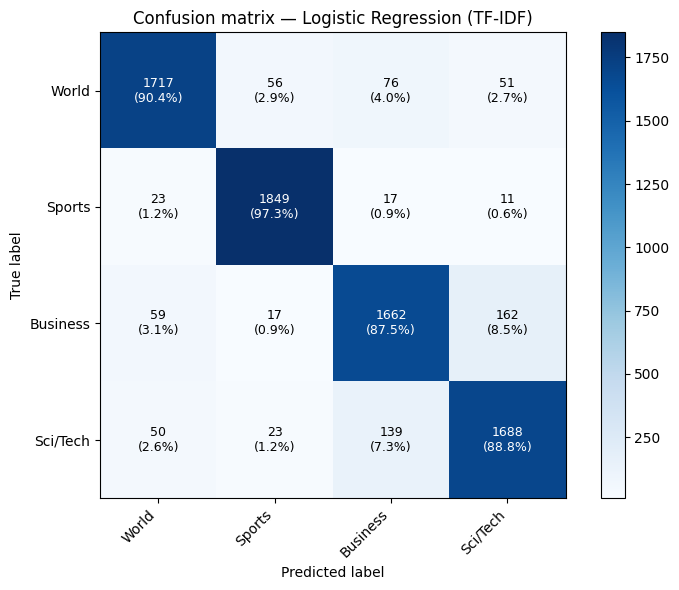

Saved confusion_matrix_lr.png


In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix — Logistic Regression (TF-IDF)")

# Annotate each cell with count + percentage
for i in range(4):
    for j in range(4):
        count = cm[i, j]
        pct   = count / cm[i].sum() * 100
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{count}\n({pct:.1f}%)",
                ha="center", va="center",
                color=color, fontsize=9)

plt.tight_layout()
plt.savefig("../data/confusion_matrix_lr.png", dpi=150)
plt.show()
print("Saved confusion_matrix_lr.png")

In [8]:
# Logistic Regression is interpretable — you can read its reasoning
# coef_ shape: (n_classes, n_features) = (4, 10000)
with open("../model/artifacts/tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

vocab = vectorizer.get_feature_names_out()

print("\nTop 15 words pushing TOWARD each class:")
print("="*60)
for class_idx, class_name in LABEL_MAP.items():
    # Coefficients for this class
    coefs = lr.coef_[class_idx]
    top_positive = np.argsort(coefs)[-15:][::-1]
    words_scores = [(vocab[i], coefs[i]) for i in top_positive]
    
    print(f"\n{class_name} (positive weights):")
    for word, score in words_scores:
        print(f"  {word:<25} {score:+.4f}")

print("\n\nTop 10 words pushing AWAY from Business:")
coefs_business = lr.coef_[2]
top_negative   = np.argsort(coefs_business)[:10]
for i in top_negative:
    print(f"  {vocab[i]:<25} {coefs_business[i]:+.4f}")


Top 15 words pushing TOWARD each class:

World (positive weights):
  afp                       +5.8577
  iraq                      +5.8558
  afp afp                   +5.0566
  nuclear                   +4.8756
  iraqi                     +4.7787
  canadian press            +4.7481
  president                 +4.6128
  athens greece             +4.4083
  iran                      +4.3600
  un                        +4.2951
  arafat                    +4.1301
  military                  +4.1276
  troops                    +3.9646
  leader                    +3.8600
  palestinian               +3.8482

Sports (positive weights):
  coach                     +6.2293
  cup                       +6.0320
  sports                    +5.7426
  team                      +5.4269
  baseball                  +5.3718
  league                    +5.3221
  stadium                   +4.8770
  nascar                    +4.8310
  olympic                   +4.6974
  players                   +4.6329
  nb

In [9]:
# Look at actual misclassified examples — crucial for understanding model limits
test_df["pred_label"]    = y_pred
test_df["pred_name"]     = test_df["pred_label"].map(LABEL_MAP)
test_df["true_name"]     = test_df["label"].map(LABEL_MAP)
test_df["correct"]       = test_df["pred_label"] == test_df["label"]
test_df["confidence"]    = y_prob.max(axis=1).round(4)

# Focus on the hardest confusion pair
wrong_biz_as_world = test_df[
    (test_df["label"] == 2) &        # true = Business
    (test_df["pred_label"] == 0)      # predicted = World
].sort_values("confidence", ascending=False)

print(f"\nBusiness articles predicted as World: {len(wrong_biz_as_world)}")
print("\nTop 5 most confidently wrong (high confidence, wrong class):")
for _, row in wrong_biz_as_world.head(5).iterrows():
    print(f"\nText      : {row['text'][:200]}")
    print(f"Confidence: {row['confidence']:.3f} (wrongly predicted World)")


Business articles predicted as World: 59

Top 5 most confidently wrong (high confidence, wrong class):

Text      : Indonesian diplomats asked to help improve RI #39;s bad image JAKARTA (Antara): President Susilo Yudhoyono asked Indonesian diplomats on Monday to help the government improve Indonesia #39;s bad image
Confidence: 0.968 (wrongly predicted World)

Text      : EU foreign ministers hope to break deadlock over ASEM summit The European Union said Friday it  quot;hoped to reach a conclusion quot; at a meeting of foreign ministers on the participation of militar
Confidence: 0.899 (wrongly predicted World)

Text      : World briefs LONDON - A man wielding a machete and a knife attacked two security guards at the building housing the headquarters of the British domestic intelligence service MI5 on Friday, police said
Confidence: 0.897 (wrongly predicted World)

Text      : Nepal blockade 'blow to tourism' Nepal tour operators say tourists cancelled millions of  dollars of bookings

In [11]:
os.makedirs("../model/artifacts", exist_ok=True)

# Save model
with open("../model/artifacts/lr_classifier.pkl", "wb") as f:
    pickle.dump(lr, f)
print("Saved lr_classifier.pkl")

# Log experiment results to a simple JSON file
# Day 10 you'll do this properly with MLflow
import json
results = {
    "model"         : "LogisticRegression",
    "vectorizer"    : "TF-IDF (10k features, bigrams, sublinear_tf)",
    "train_samples" : len(y_train),
    "test_samples"  : len(y_test),
    "accuracy"      : round(float((y_pred == y_test).mean()), 4),
    "macro_f1"      : round(float(f1_score(y_test, y_pred, average="macro")), 4),
    "per_class_f1"  : {
        LABEL_MAP[i]: round(float(f1_score(y_test, y_pred, average=None)[i]), 4)
        for i in range(4)
    },
    "training_time_s": round(elapsed, 2)
}

with open("../model/artifacts/experiment_log.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nExperiment results:")
print(json.dumps(results, indent=2))

Saved lr_classifier.pkl

Experiment results:
{
  "model": "LogisticRegression",
  "vectorizer": "TF-IDF (10k features, bigrams, sublinear_tf)",
  "train_samples": 120000,
  "test_samples": 7600,
  "accuracy": 0.91,
  "macro_f1": 0.9099,
  "per_class_f1": {
    "World": 0.916,
    "Sports": 0.9618,
    "Business": 0.8761,
    "Sci/Tech": 0.8856
  },
  "training_time_s": 18.33
}
